## 1. Environment Setup and Project Paths

In [2]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# Set base paths
PROJECT_ROOT = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO"
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "car_damage_yolo")
CONFIG_PATH = os.path.join(PROJECT_ROOT, "config", "car_damage.yaml")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CONFIG_PATH:", CONFIG_PATH)

PROJECT_ROOT: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO
DATA_DIR: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo
CONFIG_PATH: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml


## 2. Dataset Exploration

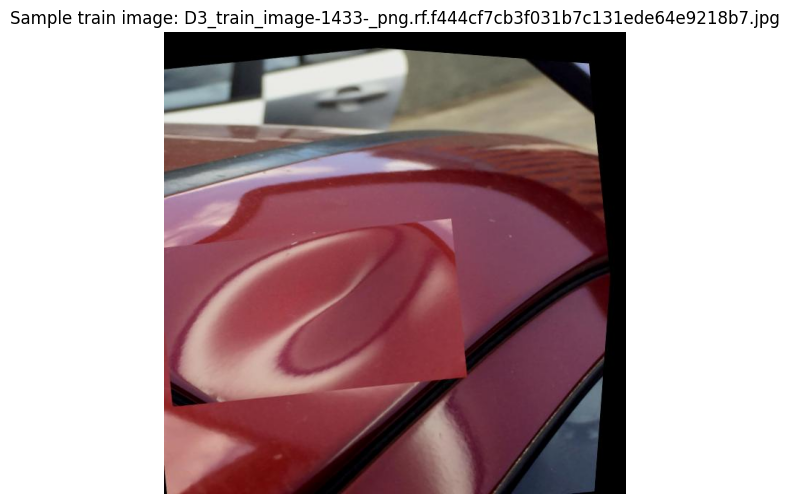

In [3]:
import random

train_images_dir = os.path.join(DATA_DIR, "images", "train")
sample_img_name = random.choice(os.listdir(train_images_dir))
sample_img_path = os.path.join(train_images_dir, sample_img_name)

img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Sample train image: {sample_img_name}")
plt.axis("off")
plt.show()

## 3. GPU and CUDA Verification

In [7]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.9.1+cu126
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 2050


## 4. YOLOv8s Model

In [8]:
model = YOLO("yolov8s.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

### 4.1 Train YOLOv8s on Car Damage Dataset

In [6]:
results = model.train(
    data=CONFIG_PATH,
    epochs=50,
    imgsz=640,
    batch=8,
    name="car_damage_yolov8s",
    project=os.path.join(PROJECT_ROOT, "models", "runs"),
    patience=10,
    device=0   
)

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car_damage_yolov8s, nbs=64, nms=False, opset=None, optimize=False,

### 4.2 Validate YOLOv8s on Validation Set

In [23]:
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
model_best = YOLO(best_weights_path)

metrics = model_best.val(
    data=CONFIG_PATH,
    imgsz=640,
    split="val"
)

metrics

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1629.51548.0 MB/s, size: 476.5 KB)
val: Scanning D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\labels\val.cache... 1907 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1907/1907  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 1961, len(boxes) = 5436. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 3.3it/s 36.9s0.3s
                   all       1907       5436      0.787      0.653      0.714      0.554
                  dent        675        993    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025009F3AA50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

### 4.3 Summary Metrics for YOLOv8s

In [24]:
import numpy as np

mean_precision = float(np.mean(metrics.box.p))  # average over classes
mean_recall    = float(np.mean(metrics.box.r))  # average over classes

summary = {
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "precision": mean_precision,
    "recall": mean_recall,
}

summary

{'mAP50': 0.7137792561800108,
 'mAP50_95': 0.5543746223060257,
 'precision': 0.7868669807070637,
 'recall': 0.6533741290936349}

### 4.4 Per-Class Performance for YOLOv8s

In [25]:
class_names = ["dent", "scratch", "crack", "glass shatter", "lamp broken", "tire flat", "rust"]

for i, name in enumerate(class_names):
    print(f"{name:15s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}")

dent             P=0.744  R=0.566
scratch          P=0.649  R=0.347
crack            P=0.680  R=0.468
glass shatter    P=0.979  R=0.959
lamp broken      P=0.851  R=0.824
tire flat        P=0.843  R=0.938
rust             P=0.761  R=0.472


## 5. YOLOv8n Model

In [13]:
model_n = YOLO("yolov8n.pt")
model_n

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

### 5.1 Train YOLOv8n (Nano Model)

In [5]:
results_n = model_n.train(
    data=CONFIG_PATH,
    epochs=50,             
    imgsz=640,
    batch=16,               
    name="car_damage_yolov8n",
    project=os.path.join(PROJECT_ROOT, "models", "runs"),
    patience=10,
    device=0
)

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car_damage_yolov8n, nbs=64, nms=False, opset=None, optimize=False

### 5.2 Validate YOLOv8n on Validation Set

In [27]:
best_n_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8n\weights\best.pt"
model_n_best = YOLO(best_n_path)

metrics_n = model_n_best.val(
    data=CONFIG_PATH,
    imgsz=640,
    split="val"
)

metrics_n


Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1177.7875.4 MB/s, size: 468.2 KB)
val: Scanning D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\labels\val.cache... 1907 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1907/1907 1.9Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 1961, len(boxes) = 5436. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 5.3it/s 22.5s0.2s
                   all       1907       5436      0.737      0.635      0.687      0.526
                  dent        675        99

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025041B07890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

### 5.3 Summary Metrics for YOLOv8n

In [28]:
import numpy as np

mean_precision_n = float(np.mean(metrics_n.box.p))
mean_recall_n    = float(np.mean(metrics_n.box.r))

summary_n = {
    "mAP50": float(metrics_n.box.map50),
    "mAP50_95": float(metrics_n.box.map),
    "precision": mean_precision_n,
    "recall": mean_recall_n,
}

summary_n

{'mAP50': 0.6865960605022527,
 'mAP50_95': 0.5261210367836942,
 'precision': 0.7372930391833895,
 'recall': 0.6350806713780898}

## 6. Compare YOLOv8s vs YOLOv8n (Accuracy vs Speed Trade-off)

In [29]:
import pandas as pd

compare_df = pd.DataFrame([
    {"Model": "YOLOv8s", "mAP50": summary["mAP50"],   "mAP50_95": summary["mAP50_95"],   "Precision": summary["precision"],   "Recall": summary["recall"]},
    {"Model": "YOLOv8n", "mAP50": summary_n["mAP50"], "mAP50_95": summary_n["mAP50_95"], "Precision": summary_n["precision"], "Recall": summary_n["recall"]},
])

compare_df

,Model,mAP50,mAP50_95,Precision,Recall
0,YOLOv8s,0.713779,0.554375,0.786867,0.653374
1,YOLOv8n,0.686596,0.526121,0.737293,0.635081


## 7. Inference on Test Set Images
### Visualizing model predictions on dataset test images


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_test_damaged-car-scratch-16930537_jpg.rf.b8db82ae3a87c827b442ff793bf5ed3e.jpg: 640x640 4 scratchs, 24.3ms
Speed: 3.0ms preprocess, 24.3ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


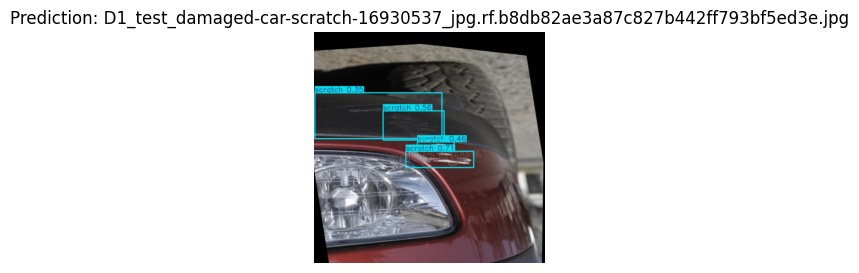


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_test_minor-dent-scratches-bumper-car-involved-accident-97896523_jpg.rf.90891d12981e5dc88bb67a5e558b3bdc.jpg: 640x640 1 scratch, 24.4ms
Speed: 1.7ms preprocess, 24.4ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


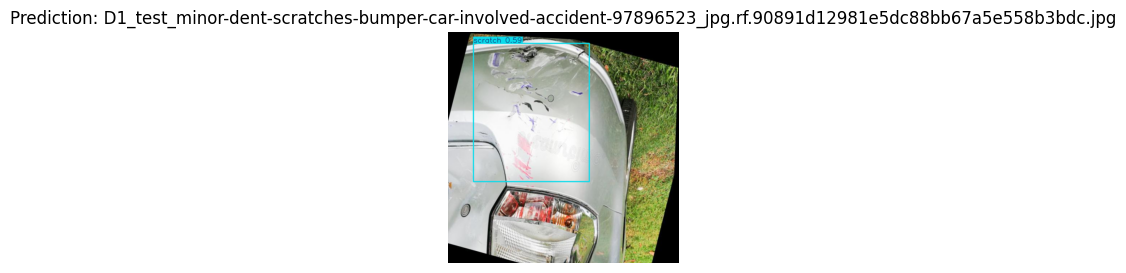


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_1_jpg.rf.cfd349c71249272d0eeb169a50725394.jpg: 640x640 7 scratchs, 26.4ms
Speed: 1.7ms preprocess, 26.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


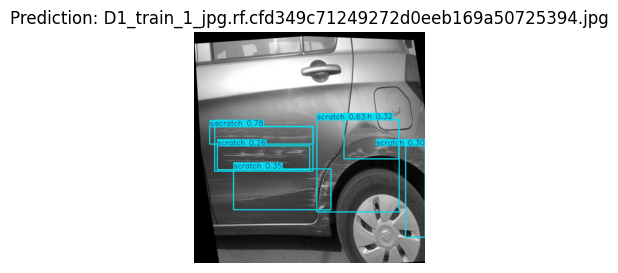


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_742cec8b48ddb02fe35069dc9bf0ad0a_jpg.rf.a73c63f04f2e871b03a298eda2604c94.jpg: 640x640 2 scratchs, 27.4ms
Speed: 1.4ms preprocess, 27.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


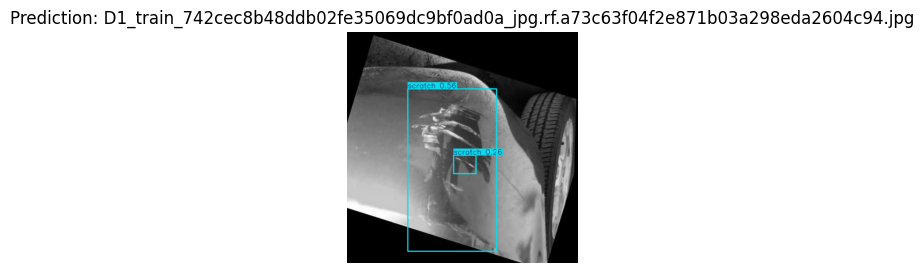


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_accident-damage-22466802_jpg.rf.9ed32571362e8045eb37c042b1047ce9.jpg: 640x640 4 dents, 4 scratchs, 26.4ms
Speed: 1.4ms preprocess, 26.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


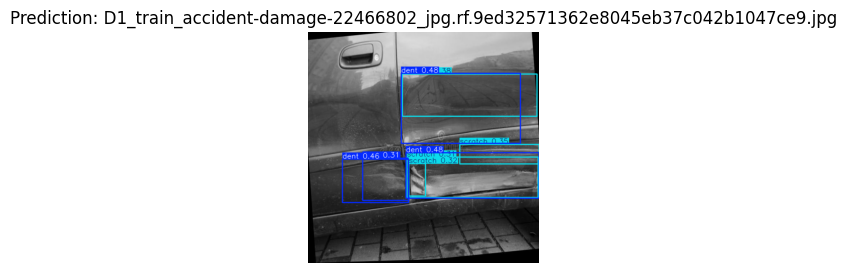


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_auto-body-repair-series-mechanic-checking-dent-white-car-bonnet-58249344_jpg.rf.ffd202561cbb4d786c10f363bc574664.jpg: 640x640 3 scratchs, 26.1ms
Speed: 1.6ms preprocess, 26.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


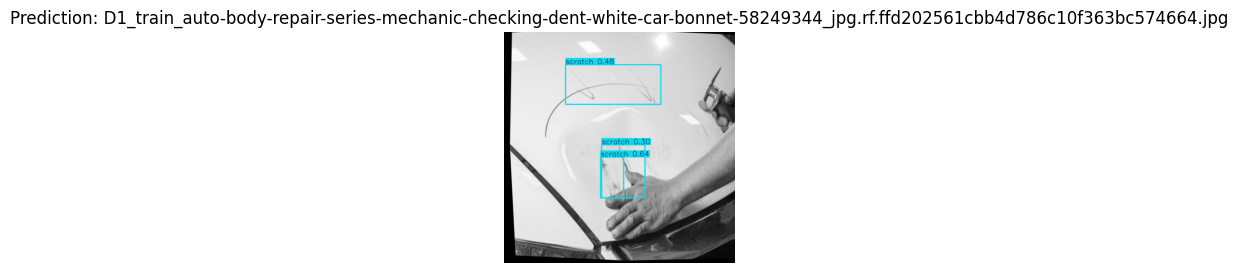

In [16]:
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
model_best = YOLO(best_weights_path)

test_dir = os.path.join(DATA_DIR, "images", "test")
test_imgs = os.listdir(test_dir)[:6]

for img_name in test_imgs:
    img_path = os.path.join(test_dir, img_name)
    results = model_best(img_path)

    for r in results:
        plotted = r.plot()
        plt.figure(figsize=(3, 3))
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {img_name}")
        plt.axis("off")
        plt.show()

## 8. Generalisation Test on External Real-World Image
### Testing the model on an image not included in the dataset


image 1/1 C:\Users\ASUS\Downloads\damage_car.jpg: 448x640 1 dent, 3 scratchs, 146.5ms
Speed: 3.5ms preprocess, 146.5ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


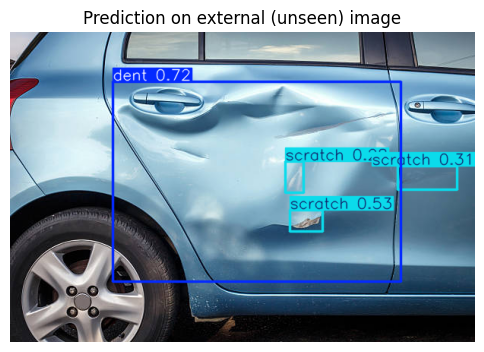

In [17]:
# Test on an external image not from the dataset
external_img_path = r"C:\Users\ASUS\Downloads\damage_car.jpg"

results = model_best(external_img_path)

for r in results:
    plotted = r.plot()
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("Prediction on external (unseen) image")
    plt.axis("off")
    plt.show()

## 9. Training History and Performance Curves
### Load YOLO training logs from results.csv

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\results.csv"

df = pd.read_csv(csv_path)

# Strip spaces from column names
df.columns = [c.strip() for c in df.columns]

print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


### 9.1 Training vs Validation Performance Plot

Using columns: metrics/mAP50(B) and train/box_loss


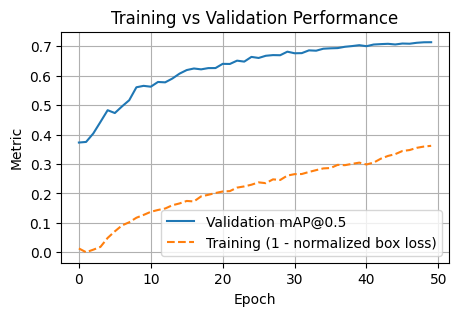

In [19]:
# Try to find the mAP and train loss columns automatically
mAP_col = [c for c in df.columns if "metrics/mAP50" in c][0]
train_loss_col = [c for c in df.columns if "train/box_loss" in c][0]

print("Using columns:", mAP_col, "and", train_loss_col)

plt.figure(figsize=(5, 3))

# Validation "accuracy" = mAP@0.5
plt.plot(df[mAP_col], label="Validation mAP@0.5")

# Training "accuracy" proxy = 1 - normalized box loss (so higher is better)
train_loss_norm = df[train_loss_col] / df[train_loss_col].max()
plt.plot(1 - train_loss_norm, label="Training (1 - normalized box loss)", linestyle="--")

plt.title("Training vs Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

## 10. Real-Time Car Damage Detection Prototype
### Live detection using webcam (OpenCV + YOLOv8)

In [20]:
import cv2

# Use the best YOLOv8s weights for demo
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
demo_model = YOLO(best_weights_path)

# 0 = default webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Cannot open webcam.")
else:
    print("Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLO on the frame
        results = demo_model(frame)

        # Plot detections on the frame
        annotated_frame = results[0].plot()

        cv2.imshow("Car Damage Detection - Webcam Demo", annotated_frame)

        # Exit on 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Press 'q' to quit.

0: 480x640 1 dent, 66.2ms
Speed: 24.6ms preprocess, 66.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 17.2ms
Speed: 1.6ms preprocess, 17.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 13.5ms
Speed: 1.7ms preprocess, 13.5ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 14.7ms
Speed: 1.3ms preprocess, 14.7ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 13.3ms
Speed: 1.3ms preprocess, 13.3ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 13.3ms
Speed: 1.4ms preprocess, 13.3ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 13.2ms
Speed: 1.5ms preprocess, 13.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dent, 12.9ms
Speed: 1.5ms preprocess, 12.9ms inference, 2.1ms postprocess per image at shape (1, 3

### 11. Detection on a Pre-recorded Video

In [21]:
video_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\car_damage_video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = demo_model(frame)
        annotated_frame = results[0].plot()

        cv2.imshow("Car Damage Detection - Video Demo", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


0: 384x640 3 scratchs, 2 glass shatters, 1 tire flat, 111.7ms
Speed: 25.5ms preprocess, 111.7ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 2 glass shatters, 1 lamp broken, 1 tire flat, 13.7ms
Speed: 2.9ms preprocess, 13.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 3 glass shatters, 1 tire flat, 13.9ms
Speed: 2.5ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 scratchs, 2 glass shatters, 1 tire flat, 14.8ms
Speed: 2.5ms preprocess, 14.8ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 scratchs, 2 glass shatters, 1 tire flat, 13.9ms
Speed: 2.2ms preprocess, 13.9ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 1 crack, 2 glass shatters, 1 tire flat, 14.0ms
Speed: 2.2ms preprocess, 14.0ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dent,